# CPU Frequency and Energy Consumption Analysis

This notebook analyzes the relationship between CPU frequency scaling and energy consumption.
The plots from ```scaling_freq_pros/scaling_graph``` is with speedstep.
Men ser forstatt at vi ikke booster, så resultater er fortsatt gyldige (håper det).

## Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Load CSV Data

In [2]:
# Load the data
df = pd.read_csv('scaling_freq_pros/scaling_graph')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (16, 9)

Columns: ['target_ratio', 'target_freq_ghz', 'current_ratio', 'current_freq_ghz', 'mperf_cycles', 'aperf_cycles', 'actual_freq_ghz', 'energy_j', 'bench_cycles']


,target_ratio,target_freq_ghz,current_ratio,current_freq_ghz,mperf_cycles,aperf_cycles,actual_freq_ghz,energy_j,bench_cycles
0,31,3.1,31,3.1,11488904688,11488904653,3.1,63.4896,11488897780
1,30,3.0,30,3.0,11871661892,11488705022,3.0,63.1358,11871655166
2,29,2.9,29,2.9,12281140520,11488808837,2.9,62.2610,12281133516
3,28,2.8,28,2.8,12719027990,11488154278,2.8,61.9681,12719020833
4,27,2.7,27,2.7,13190431484,11488440299,2.7,61.3518,13190424116


## Explore the Dataset

In [3]:
# Display summary statistics
df.describe()

,target_ratio,target_freq_ghz,current_ratio,current_freq_ghz,mperf_cycles,aperf_cycles,actual_freq_ghz,energy_j,bench_cycles
count,16.000000,16.000000,16.000000,16.000000,1.600000e+01,1.600000e+01,16.000000,16.000000,1.600000e+01
mean,23.500000,2.350000,23.500000,2.350000,1.578251e+10,1.148886e+10,2.350000,61.292438,1.578250e+10
std,4.760952,0.476095,4.760952,0.476095,3.355700e+09,4.273365e+05,0.476095,1.077992,3.355698e+09
min,16.000000,1.600000,16.000000,1.600000,1.148890e+10,1.148815e+10,1.600000,60.019700,1.148890e+10
25%,19.750000,1.975000,19.750000,1.975000,1.307258e+10,1.148858e+10,1.975000,60.401050,1.307257e+10
50%,23.500000,2.350000,23.500000,2.350000,1.516232e+10,1.148877e+10,2.350000,61.104350,1.516231e+10
75%,27.250000,2.725000,27.250000,2.725000,1.804304e+10,1.148906e+10,2.725000,62.029800,1.804303e+10
max,31.000000,3.100000,31.000000,3.100000,2.225930e+10,1.148974e+10,3.100000,63.489600,2.225929e+10


## Energy vs Frequency Plot

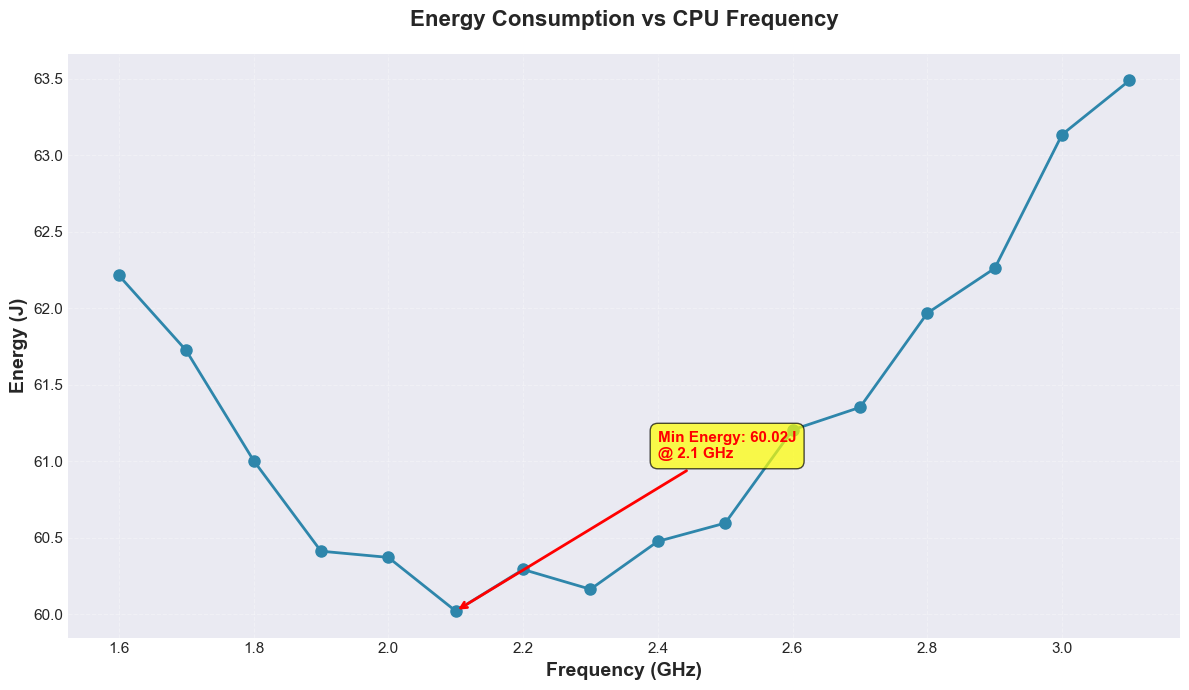


Energy Range:
  Minimum: 60.0197 J at 2.1 GHz
  Maximum: 63.4896 J at 3.1 GHz
  Difference: 3.4699 J


In [4]:
# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(df['actual_freq_ghz'], df['energy_j'], marker='o', linewidth=2, markersize=8, color='#2E86AB')

# Customize the plot
plt.xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
plt.ylabel('Energy (J)', fontsize=14, fontweight='bold')
plt.title('Energy Consumption vs CPU Frequency', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add min energy annotation
min_energy_idx = df['energy_j'].idxmin()
min_energy = df.loc[min_energy_idx, 'energy_j']
min_freq = df.loc[min_energy_idx, 'actual_freq_ghz']
plt.annotate(f'Min Energy: {min_energy:.2f}J\n@ {min_freq:.1f} GHz',
             xy=(min_freq, min_energy),
             xytext=(min_freq + 0.3, min_energy + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# Print energy range
print(f"\nEnergy Range:")
print(f"  Minimum: {df['energy_j'].min():.4f} J at {df.loc[df['energy_j'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df['energy_j'].max():.4f} J at {df.loc[df['energy_j'].idxmax(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Difference: {df['energy_j'].max() - df['energy_j'].min():.4f} J")

## Energy Efficiency Metrics

In [5]:
# Calculate energy per GHz
df['energy_per_ghz'] = df['energy_j'] / df['actual_freq_ghz']

# Find most energy-efficient frequency
most_efficient_idx = df['energy_per_ghz'].idxmin()
most_efficient_freq = df.loc[most_efficient_idx, 'actual_freq_ghz']
most_efficient_energy = df.loc[most_efficient_idx, 'energy_j']
most_efficient_ratio = df.loc[most_efficient_idx, 'energy_per_ghz']

print("Energy Efficiency Analysis:")
print(f"  Most efficient frequency: {most_efficient_freq:.1f} GHz")
print(f"  Energy consumed: {most_efficient_energy:.4f} J")
print(f"  Energy per GHz: {most_efficient_ratio:.4f} J/GHz")
print("\nEnergy per GHz at all frequencies:")
print(df[['actual_freq_ghz', 'energy_j', 'energy_per_ghz']].sort_values('energy_per_ghz'))

Energy Efficiency Analysis:
  Most efficient frequency: 3.1 GHz
  Energy consumed: 63.4896 J
  Energy per GHz: 20.4805 J/GHz

Energy per GHz at all frequencies:
    actual_freq_ghz  energy_j  energy_per_ghz
0               3.1   63.4896       20.480516
1               3.0   63.1358       21.045267
2               2.9   62.2610       21.469310
3               2.8   61.9681       22.131464
4               2.7   61.3518       22.722889
5               2.6   61.2047       23.540269
6               2.5   60.5949       24.237960
7               2.4   60.4753       25.198042
8               2.3   60.1622       26.157478
9               2.2   60.2916       27.405273
10              2.1   60.0197       28.580810
11              2.0   60.3706       30.185300
12              1.9   60.4112       31.795368
13              1.8   61.0040       33.891111
14              1.7   61.7236       36.308000
15              1.6   62.2149       38.884313


## Power (Wattage) vs Frequency Plot

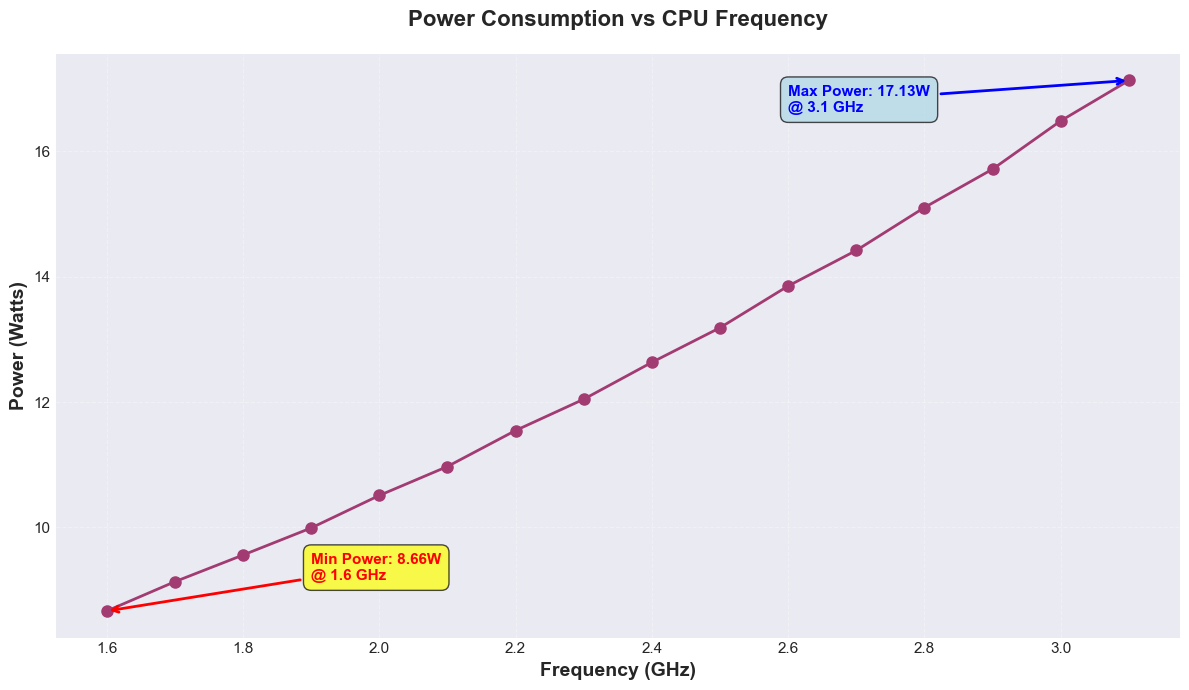


Power Statistics:
  Minimum: 8.6645 W at 1.6 GHz
  Maximum: 17.1311 W at 3.1 GHz
  Difference: 8.4666 W
  Average: 12.5587 W

Execution time range: 3.706096s to 7.180415s


In [6]:
# Calculate power (wattage) from energy and time
# Time = cycles / (frequency in Hz)
# Power = Energy / Time (Watts)

df['time_s'] = df['bench_cycles'] / (3.1 * 1e9)
df['power_w'] = df['energy_j'] / df['time_s']

# Create the wattage vs frequency plot
plt.figure(figsize=(12, 7))
plt.plot(df['actual_freq_ghz'], df['power_w'], marker='o', linewidth=2, markersize=8, color='#A23B72')

# Customize the plot
plt.xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
plt.ylabel('Power (Watts)', fontsize=14, fontweight='bold')
plt.title('Power Consumption vs CPU Frequency', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add min power annotation
min_power_idx = df['power_w'].idxmin()
min_power = df.loc[min_power_idx, 'power_w']
min_power_freq = df.loc[min_power_idx, 'actual_freq_ghz']
plt.annotate(f'Min Power: {min_power:.2f}W\n@ {min_power_freq:.1f} GHz',
             xy=(min_power_freq, min_power),
             xytext=(min_power_freq + 0.3, min_power + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Add max power annotation
max_power_idx = df['power_w'].idxmax()
max_power = df.loc[max_power_idx, 'power_w']
max_power_freq = df.loc[max_power_idx, 'actual_freq_ghz']
plt.annotate(f'Max Power: {max_power:.2f}W\n@ {max_power_freq:.1f} GHz',
             xy=(max_power_freq, max_power),
             xytext=(max_power_freq - 0.5, max_power - 0.5),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=11, fontweight='bold', color='blue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# Print power statistics
print(f"\nPower Statistics:")
print(f"  Minimum: {df['power_w'].min():.4f} W at {df.loc[df['power_w'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df['power_w'].max():.4f} W at {df.loc[df['power_w'].idxmax(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Difference: {df['power_w'].max() - df['power_w'].min():.4f} W")
print(f"  Average: {df['power_w'].mean():.4f} W")
print(f"\nExecution time range: {df['time_s'].min():.6f}s to {df['time_s'].max():.6f}s")

## Analysis with EIST Enabled Data

In [7]:
# Load the EIST enabled data
df_eist = pd.read_csv('scaling_freq_pros/scaling_graph_with_eist_enabled.csv')

# Calculate time and power for EIST data
df_eist['time_s'] = df_eist['bench_cycles'] / (3.10 * 1e9)
df_eist['power_w'] = df_eist['energy_j'] / df_eist['time_s']
df_eist['energy_per_ghz'] = df_eist['energy_j'] / df_eist['actual_freq_ghz']

print(f"EIST Dataset shape: {df_eist.shape}")
print(f"\nFirst few rows:")
df_eist.head(10)

EIST Dataset shape: (16, 12)

First few rows:


,target_ratio,target_freq_ghz,current_ratio,current_freq_ghz,mperf_cycles,aperf_cycles,actual_freq_ghz,energy_j,bench_cycles,time_s,power_w,energy_per_ghz
0,31,3.1,31,3.1,11488783752,11488783719,3.1,63.4296,11488776580,3.706057,17.115117,20.461161
1,30,3.0,30,3.0,11871567486,11488613661,3.0,63.0979,11871560710,3.829536,16.476645,21.032633
2,29,2.9,29,2.9,12281440200,11489089187,2.9,62.2713,12281433304,3.961753,15.718119,21.472862
3,28,2.8,28,2.8,12719370990,11488464086,2.8,61.9919,12719363523,4.103020,15.108845,22.139964
4,27,2.7,27,2.7,13190540616,11488535332,2.7,61.3544,13190533168,4.255011,14.419329,22.723852
5,26,2.6,26,2.6,13697731064,11488419573,2.6,61.1427,13697723322,4.418620,13.837509,23.516423
6,25,2.5,25,2.5,14245667888,11488441821,2.5,60.6017,14245659844,4.595374,13.187544,24.240680
7,24,2.4,24,2.4,14839398257,11488566356,2.4,60.3911,14839389928,4.786900,12.615910,25.162958
8,23,2.3,23,2.3,15483592131,11487826384,2.3,60.0504,15483583739,4.994704,12.022814,26.108870
9,22,2.2,22,2.2,16188382848,11488529729,2.2,60.2083,16188374148,5.222056,11.529616,27.367409


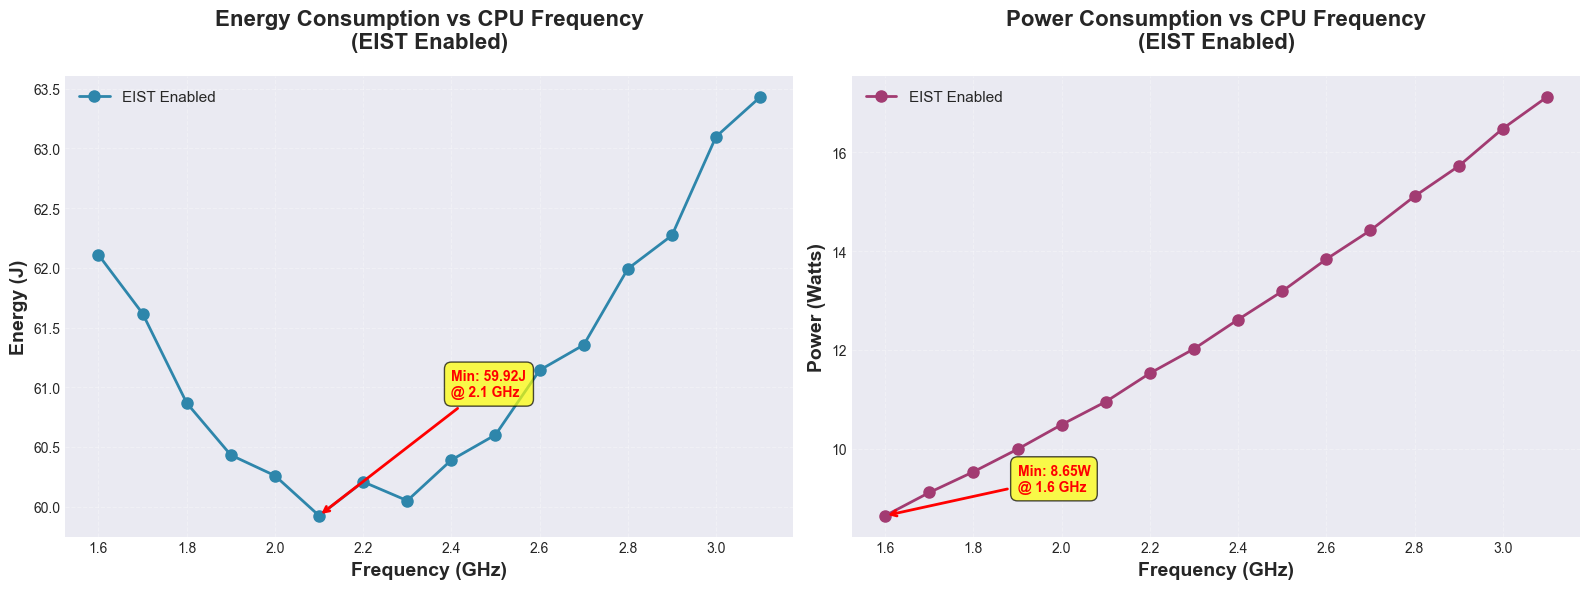


EIST Enabled - Energy Statistics:
  Minimum: 59.9250 J at 2.1 GHz
  Maximum: 63.4296 J at 3.1 GHz

EIST Enabled - Power Statistics:
  Minimum: 8.6493 W at 1.6 GHz
  Maximum: 17.1151 W at 3.1 GHz
  Average: 12.5483 W


In [8]:
# Create comparison plots for Energy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Energy vs Frequency - EIST Enabled
ax1.plot(df_eist['actual_freq_ghz'], df_eist['energy_j'], marker='o', linewidth=2, markersize=8, color='#2E86AB', label='EIST Enabled')
ax1.set_xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Energy (J)', fontsize=14, fontweight='bold')
ax1.set_title('Energy Consumption vs CPU Frequency\n(EIST Enabled)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)

# Add min energy annotation for EIST
min_energy_idx_eist = df_eist['energy_j'].idxmin()
min_energy_eist = df_eist.loc[min_energy_idx_eist, 'energy_j']
min_freq_eist = df_eist.loc[min_energy_idx_eist, 'actual_freq_ghz']
ax1.annotate(f'Min: {min_energy_eist:.2f}J\n@ {min_freq_eist:.1f} GHz',
             xy=(min_freq_eist, min_energy_eist),
             xytext=(min_freq_eist + 0.3, min_energy_eist + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Plot 2: Power vs Frequency - EIST Enabled
ax2.plot(df_eist['actual_freq_ghz'], df_eist['power_w'], marker='o', linewidth=2, markersize=8, color='#A23B72', label='EIST Enabled')
ax2.set_xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Power (Watts)', fontsize=14, fontweight='bold')
ax2.set_title('Power Consumption vs CPU Frequency\n(EIST Enabled)', fontsize=16, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

# Add min power annotation for EIST
min_power_idx_eist = df_eist['power_w'].idxmin()
min_power_eist = df_eist.loc[min_power_idx_eist, 'power_w']
min_power_freq_eist = df_eist.loc[min_power_idx_eist, 'actual_freq_ghz']
ax2.annotate(f'Min: {min_power_eist:.2f}W\n@ {min_power_freq_eist:.1f} GHz',
             xy=(min_power_freq_eist, min_power_eist),
             xytext=(min_power_freq_eist + 0.3, min_power_eist + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nEIST Enabled - Energy Statistics:")
print(f"  Minimum: {df_eist['energy_j'].min():.4f} J at {df_eist.loc[df_eist['energy_j'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df_eist['energy_j'].max():.4f} J at {df_eist.loc[df_eist['energy_j'].idxmax(), 'actual_freq_ghz']:.1f} GHz")

print(f"\nEIST Enabled - Power Statistics:")
print(f"  Minimum: {df_eist['power_w'].min():.4f} W at {df_eist.loc[df_eist['power_w'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df_eist['power_w'].max():.4f} W at {df_eist.loc[df_eist['power_w'].idxmax(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Average: {df_eist['power_w'].mean():.4f} W")

## Analysis with EIST Enabled + Boost Frequencies Data

In [ ]:
# Load the EIST + Boost enabled data
df_boost = pd.read_csv('scaling_freq_pros/scaling_graph_with_eist_enabled_boost_allcoresenabled.csv')

# Calculate time and power for boost data
df_boost['time_s'] = df_boost['bench_cycles'] / (3.10 * 1e9)
df_boost['power_w'] = df_boost['energy_j'] / df_boost['time_s']
df_boost['energy_per_ghz'] = df_boost['energy_j'] / df_boost['actual_freq_ghz']

print(f"EIST + Boost Dataset shape: {df_boost.shape}")
print(f"\nFrequency range: {df_boost['actual_freq_ghz'].min():.1f} - {df_boost['actual_freq_ghz'].max():.1f} GHz")
print(f"\nFirst few rows:")
df_boost.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'scaling_freq_pros/scaling_graph_with_eist_enabledl_boost_allcoresenabled.csv'

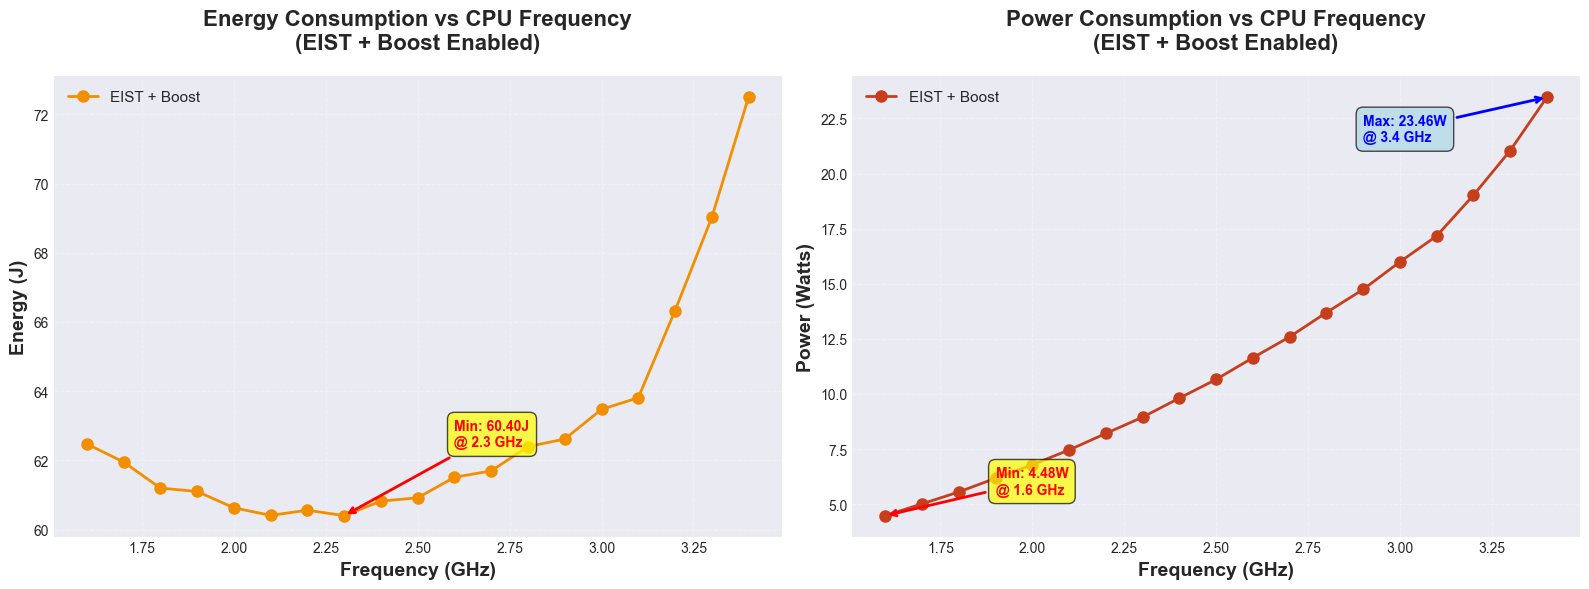


EIST + Boost - Energy Statistics:
  Minimum: 60.4027 J at 2.3 GHz
  Maximum: 72.4956 J at 3.4 GHz
  Range: 12.0929 J

EIST + Boost - Power Statistics:
  Minimum: 4.4761 W at 1.6 GHz
  Maximum: 23.4616 W at 3.4 GHz
  Average: 11.7051 W
  Range: 18.9855 W


In [ ]:
# Create plots for EIST + Boost data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Energy vs Frequency - EIST + Boost
ax1.plot(df_boost['actual_freq_ghz'], df_boost['energy_j'], marker='o', linewidth=2, markersize=8, color='#F18F01', label='EIST + Boost')
ax1.set_xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Energy (J)', fontsize=14, fontweight='bold')
ax1.set_title('Energy Consumption vs CPU Frequency\n(EIST + Boost Enabled)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)

# Add min energy annotation
min_energy_idx_boost = df_boost['energy_j'].idxmin()
min_energy_boost = df_boost.loc[min_energy_idx_boost, 'energy_j']
min_freq_boost = df_boost.loc[min_energy_idx_boost, 'actual_freq_ghz']
ax1.annotate(f'Min: {min_energy_boost:.2f}J\n@ {min_freq_boost:.1f} GHz',
             xy=(min_freq_boost, min_energy_boost),
             xytext=(min_freq_boost + 0.3, min_energy_boost + 2),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Plot 2: Power vs Frequency - EIST + Boost
ax2.plot(df_boost['actual_freq_ghz'], df_boost['power_w'], marker='o', linewidth=2, markersize=8, color='#C73E1D', label='EIST + Boost')
ax2.set_xlabel('Frequency (GHz)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Power (Watts)', fontsize=14, fontweight='bold')
ax2.set_title('Power Consumption vs CPU Frequency\n(EIST + Boost Enabled)', fontsize=16, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

# Add min and max power annotations
min_power_idx_boost = df_boost['power_w'].idxmin()
min_power_boost = df_boost.loc[min_power_idx_boost, 'power_w']
min_power_freq_boost = df_boost.loc[min_power_idx_boost, 'actual_freq_ghz']
ax2.annotate(f'Min: {min_power_boost:.2f}W\n@ {min_power_freq_boost:.1f} GHz',
             xy=(min_power_freq_boost, min_power_boost),
             xytext=(min_power_freq_boost + 0.3, min_power_boost + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

max_power_idx_boost = df_boost['power_w'].idxmax()
max_power_boost = df_boost.loc[max_power_idx_boost, 'power_w']
max_power_freq_boost = df_boost.loc[max_power_idx_boost, 'actual_freq_ghz']
ax2.annotate(f'Max: {max_power_boost:.2f}W\n@ {max_power_freq_boost:.1f} GHz',
             xy=(max_power_freq_boost, max_power_boost),
             xytext=(max_power_freq_boost - 0.5, max_power_boost - 2),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=10, fontweight='bold', color='blue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nEIST + Boost - Energy Statistics:")
print(f"  Minimum: {df_boost['energy_j'].min():.4f} J at {df_boost.loc[df_boost['energy_j'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df_boost['energy_j'].max():.4f} J at {df_boost.loc[df_boost['energy_j'].idxmax(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Range: {df_boost['energy_j'].max() - df_boost['energy_j'].min():.4f} J")

print(f"\nEIST + Boost - Power Statistics:")
print(f"  Minimum: {df_boost['power_w'].min():.4f} W at {df_boost.loc[df_boost['power_w'].idxmin(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Maximum: {df_boost['power_w'].max():.4f} W at {df_boost.loc[df_boost['power_w'].idxmax(), 'actual_freq_ghz']:.1f} GHz")
print(f"  Average: {df_boost['power_w'].mean():.4f} W")
print(f"  Range: {df_boost['power_w'].max() - df_boost['power_w'].min():.4f} W")